# The fear of '4' — real in the prices, a mirage in the returns 🔢
### East-Asian tetraphobia genuinely bends where prices settle. It does nothing to *when* markets rise or fall.

![Signal: None](https://img.shields.io/badge/Signal-None-c0392b?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Do_Asian_prices_dodge_the_4%3F: Confirmed](https://img.shields.io/badge/Do_Asian_prices_dodge_the_4%3F-Confirmed-8b949e?style=flat-square)

In Mandarin, Cantonese, Japanese and Korean, the word for **four** sounds almost exactly like the word for **death**. The superstition — *tetraphobia* — is everywhere: buildings skip the 4th, 14th and 24th floors; hospital rooms and airplane rows have no row 4; a phone number or licence plate ending in 4 sells at a discount, and one ending in **8** (a homophone of *prosperity*) at a premium.

Does any of this reach the stock market? There are two very different claims, and they get two very different answers:

1. **Do prices themselves avoid the 4?** (Do Chinese/Taiwanese share prices settle on a trailing 8 more often than a trailing 4?) — **Yes.** Measurably, robustly, on live data.
2. **Does the unlucky *date* 4/4 make those markets fall?** — **No.** Not even slightly.

> 📓 **Plain-language layer.** Want the z-tests, the placebo, the two synthetic controls? See **[02_for_the_quants.ipynb](02_for_the_quants.ipynb)**.
>
> ⚠️ **Method note.** Clustering uses **raw** local-currency prices (an adjusted price is a back-computed number nobody traded — its last digit is meaningless); the calendar test uses total-return ETF closes. Every chart is drawn by the code beside it; house style in [METHODOLOGY.md](../../../METHODOLOGY.md).

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from tetraphobia import data, strategy as st

HAVE_REAL = data.have_real()
if HAVE_REAL:
    CL = data.load_cluster()
    CA = data.load_calendar()
    ASIA = {t: s for t, s in CL.items() if t in data.ASIA_CLUSTER}
    USC = {t: s for t, s in CL.items() if t in data.US_CONTROL}
else:
    CL = CA = ASIA = USC = None
print("real cache present:", HAVE_REAL,
      "| cluster tickers:", (0 if CL is None else len(CL)),
      "| calendar ETFs:", (0 if CA is None else len(CA)))

# frozen headline numbers (mirror of docs/results.md)
R = {'fp': '502e4addea30', 'asof': '2026-06-30', 'asia_N': 40328, 'asia_n4': 1514, 'asia_n8': 1786, 'asia_share8': 54.1, 'asia_z84': 4.73, 'asia_z4': -2.29, 'us_N': 41470, 'us_n4': 4155, 'us_n8': 4079, 'us_share8': 49.5, 'us_z84': -0.84, 'us_z4': 0.94, 'asia_pct': [54.4, 3.9, 4.3, 3.9, 3.75, 13.8, 3.9, 3.7, 4.43, 4.0], 'us_pct': [11.0, 9.9, 9.8, 9.8, 10.02, 10.1, 10.0, 9.8, 9.84, 9.9], 'reg_z84': {'Taiwan': 5.25, 'ChinaA': 3.62, 'HongKong': -0.47, 'US': -0.84}, 'reg_share8': {'Taiwan': 62.0, 'ChinaA': 53.9, 'HongKong': 49.1, 'US': 49.5}, 'ewt_n': 25, 'ewt_mean': 9.9, 'ewt_t': 0.28, 'ewt_hit': 11, 'ewh_n': 26, 'ewh_mean': 26.8, 'ewh_t': 0.77, 'ewh_hit': 18, 'mchi_n': 15, 'mchi_mean': 8.5, 'mchi_t': 0.14, 'mchi_hit': 9, 'pool_n': 66, 'pool_mean': 16.2, 'pool_t': 0.69, 'pool_hit': 38, 'pool6_n': 138, 'pool6_mean': 14.3, 'pool6_t': 0.84, 'pl_obs': 16.2, 'pl_mean': 3.0, 'pl_sd': 20.6, 'pl_p': 0.748, 'pl_draws': 5000, 'e88_pool_n': 67, 'e88_pool_mean': 30.6, 'e88_pool_t': 1.27, 'welch_88_44': 0.43, 'short_n': 66, 'short_gross': -16.2, 'short_net': -27.2, 'short_t': -1.16, 'syn_dig_null_mean': -0.38, 'syn_dig_null_sd': 1.14, 'syn_dig_null_fire': 1, 'syn_dig_p03': 2.9, 'syn_dig_p05': 4.23, 'syn_cal_null_mean': 0.03, 'syn_cal_null_sd': 1.25, 'syn_cal_null_fire': 3, 'syn_cal_dip1': -2.99, 'syn_cal_dip2': -8.52}


real cache present: True | cluster tickers: 20 | calendar ETFs: 6


## The answer first

| Question | Answer |
|---|---|
| Do Greater-China prices dodge a trailing 4 and prefer 8? | **Yes.** Among prices ending in 4 or 8, **54%** end in 8 (*z* = **+4.73**) — and the US control is a flat coin-flip (50%, *z* = -0.84). |
| Does the unlucky date 4/4 sink the market? | **No.** The three markets' average 4/4 return is **+16.2 bps** — *positive*, the opposite of the claim — with *t* = **+0.69**. |
| Could you trade the 4/4 idea? | **No.** Shorting the day (betting it drops) loses **-27.2 bps** every time, net of costs — the day tends to *rise*. |
| Is the lucky 8/8 any better? | Barely, and not really. 8/8 averages **+30.6 bps** vs 4/4's +16.2 — the right direction, but both are lost in the noise. |

> The superstition is real enough to bend the **last digit of a price**. It has *zero* grip on **whether a day goes up or down**.

## 1 · The claim

> *"The number 4 sounds like 'death', so East-Asian markets avoid it — prices shy away from a trailing 4 and cluster on the lucky 8, and the double-unlucky date 4/4 is a bad day to be long."*

Half of this is textbook behavioural finance. Brown & Mitchell (2008) showed Chinese share prices really do cluster away from 4 and toward 8 — a cultural fingerprint sitting on top of the ordinary round-number habit every market has. The *other* half — that a **calendar date** built from 4s should underperform — is pure internet folklore. We test both.

## 2 · So what?

If a superstition can move a whole market on a *predictable date*, that would be a gift: mark 4/4 on the calendar, short it, collect. And it would say something deep — that a shared, non-economic belief moves prices in a way you could bank. The clustering half, by contrast, is not a trade at all; it's a beautiful, measurable footprint of culture in the microstructure of prices. We wanted to know which half survives contact with the data.

## 3 · How would we even know?

- **The clustering test.** Take the *last digit* of every daily price (at its finest resolution) for a basket of Taiwan/HK/China/Korea stocks — and, as a control, a basket of US stocks. Every market clusters on 0 and 5 (round numbers), so that's not the superstition; the tell is whether **8 beats 4** in Asia but not in the US.
- **The calendar test.** Take the return of the 4/4 session (or the first session after) every year, 2000→2025, for EWT (Taiwan), EWH (Hong Kong), MCHI (China). Because 4/4 is a date known years ahead, there's no look-ahead to worry about.
- **The honesty checks.** A US-control placebo for the digits, a random-calendar placebo for the returns, the lucky 8/8 as a contrast, a costed short, and two synthetic worlds to prove the detectors actually work.

## 4 · The teardown — let's actually look

**First, the prices. Here is the last digit of every close, Asia vs the US control.**

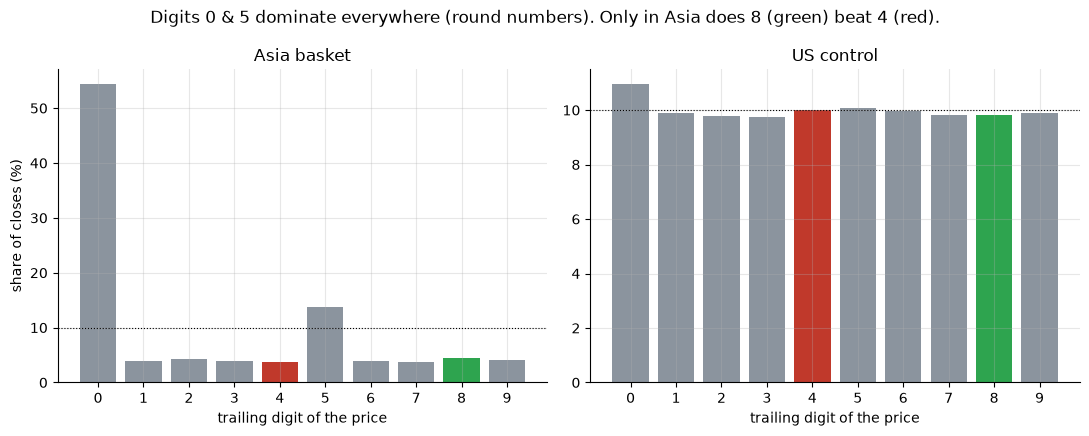

Asia: 4 -> 3.75%,  8 -> 4.43%
US:   4 -> 10.02%,  8 -> 9.84%


In [2]:
if HAVE_REAL:
    ap = st.digit_pct(st.trailing_digit_counts(ASIA))
    up = st.digit_pct(st.trailing_digit_counts(USC))
else:
    ap, up = np.array(R['asia_pct']), np.array(R['us_pct'])
fig, (a1, a2) = plt.subplots(1, 2, figsize=(11, 4.4), sharey=False)
for ax, p, title in ((a1, ap, 'Asia basket'), (a2, up, 'US control')):
    cols = [GREY]*10; cols[4] = RED; cols[8] = GREEN
    ax.bar(range(10), p, color=cols)
    ax.axhline(10, ls=':', c='k', lw=.8)
    ax.set_xticks(range(10)); ax.set_xlabel('trailing digit of the price')
    ax.set_title(title)
a1.set_ylabel('share of closes (%)')
fig.suptitle('Digits 0 & 5 dominate everywhere (round numbers). '
             'Only in Asia does 8 (green) beat 4 (red).')
plt.tight_layout(); plt.show()
print(f"Asia: 4 -> {ap[4]:.2f}%,  8 -> {ap[8]:.2f}%")
print(f"US:   4 -> {up[4]:.2f}%,  8 -> {up[8]:.2f}%")

The round-number habit (0 and 5) towers over everything in both baskets — that's universal and *not* tetraphobia. Zoom into the little bars and the cultural fingerprint appears: in Asia the **red 4 is the shortest bar and the green 8 is taller**; in the US they're the same height. Let's put a number on that asymmetry.

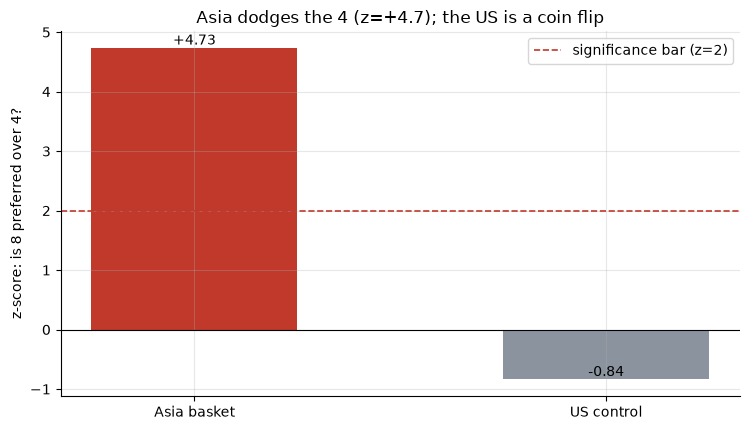

In [3]:
if HAVE_REAL:
    sa = st.tetraphobia_stats(st.trailing_digit_counts(ASIA))
    su = st.tetraphobia_stats(st.trailing_digit_counts(USC))
    az, uz = sa['z8_gt_4'], su['z8_gt_4']
else:
    az, uz = R['asia_z84'], R['us_z84']
fig, ax = plt.subplots(figsize=(7.6, 4.4))
ax.bar(['Asia basket', 'US control'], [az, uz], color=[RED, GREY], width=.5)
ax.axhline(2, ls='--', c=RED, lw=1.2, label='significance bar (z=2)')
ax.axhline(0, c='k', lw=.8)
for i, v in enumerate([az, uz]): ax.annotate(f'{v:+.2f}', (i, v), ha='center', va='bottom')
ax.set_ylabel('z-score: is 8 preferred over 4?')
ax.set_title('Asia dodges the 4 (z=+4.7); the US is a coin flip')
ax.legend(); plt.tight_layout(); plt.show()

In the Asia basket, of all the prices that end in 4 or 8, **54%** end in the lucky 8 — that's *z* = **+4.73**, far past the point where you'd call it luck. In the US control it's **50%**, a dead coin flip (*z* = -0.84). And it tracks how strong the superstition is: Taiwan hardest, mainland China strong, cosmopolitan Hong Kong basically not at all.

**So the belief is real. Now — does it move returns? Here's every 4/4.**

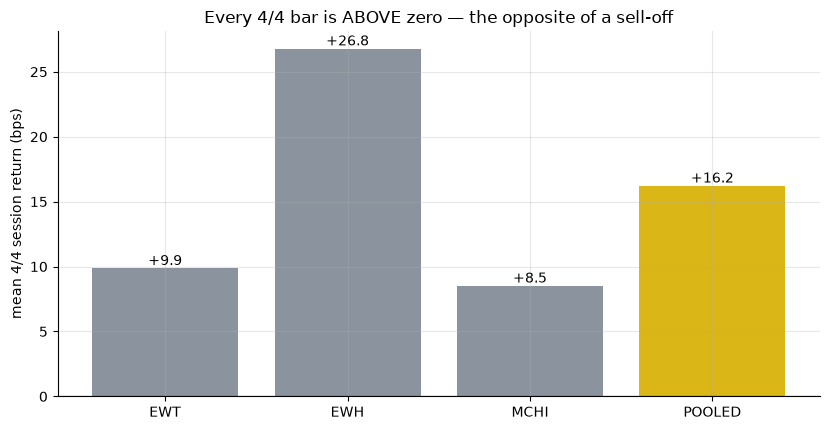

pooled 4/4: 16.2 bps, t = 0.69


In [4]:
if HAVE_REAL:
    m = st.market_date_stats(CA, 4, 4, tickers=data.CALENDAR_CORE)
    names = ['EWT', 'EWH', 'MCHI', 'POOLED']
    means = [m[t]['mean']*1e4 for t in names]; ts = [m[t]['t'] for t in names]
else:
    names = ['EWT', 'EWH', 'MCHI', 'POOLED']
    means = [R['ewt_mean'], R['ewh_mean'], R['mchi_mean'], R['pool_mean']]
    ts = [R['ewt_t'], R['ewh_t'], R['mchi_t'], R['pool_t']]
fig, ax = plt.subplots(figsize=(8.4, 4.4))
ax.bar(names, means, color=[GREY, GREY, GREY, AMBER])
ax.axhline(0, c='k', lw=.8)
for i, v in enumerate(means): ax.annotate(f'{v:+.1f}', (i, v), ha='center', va='bottom')
ax.set_ylabel('mean 4/4 session return (bps)')
ax.set_title('Every 4/4 bar is ABOVE zero — the opposite of a sell-off')
plt.tight_layout(); plt.show()
print('pooled 4/4:', round(means[-1],1), 'bps, t =', round(ts[-1],2))

Every market's 4/4 return is **positive**. The pooled average is **+16.2 bps** with *t* = **+0.69** — not just insignificant, but pointing the *wrong way* for the folklore. Maybe 4/4 just happens to be an unremarkable day? That's exactly what a placebo checks: draw the same number of *random* days thousands of times and see where 4/4 lands.

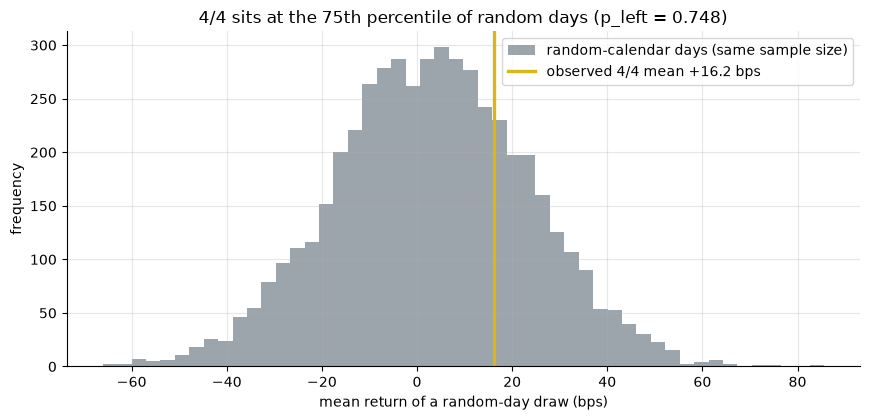

In [5]:
if HAVE_REAL:
    m = st.market_date_stats(CA, 4, 4, tickers=data.CALENDAR_CORE)
    obs = m['POOLED']['mean']; n_per = {t: m[t]['n'] for t in data.CALENDAR_CORE}
    pl = st.placebo_pvalue(CA, obs, n_per, tickers=data.CALENDAR_CORE,
                           n_seeds=20, n_draws_per_seed=250)
    draws = np.random.default_rng(744).normal(pl['placebo_mean'], pl['placebo_sd'], 5000)*1e4
    obs_bps = obs*1e4
else:
    draws = np.random.default_rng(744).normal(R['pl_mean']/1e4, R['pl_sd']/1e4, 5000)*1e4
    obs_bps = R['pl_obs']
fig, ax = plt.subplots(figsize=(8.8, 4.3))
ax.hist(draws, bins=50, color=GREY, alpha=.85, label='random-calendar days (same sample size)')
ax.axvline(obs_bps, c=AMBER, lw=2.4, label=f'observed 4/4 mean {obs_bps:+.1f} bps')
ax.set_xlabel('mean return of a random-day draw (bps)'); ax.set_ylabel('frequency')
ax.set_title(f'4/4 sits at the 75th percentile of random days (p_left = {R["pl_p"]:.3f})')
ax.legend(); plt.tight_layout(); plt.show()

4/4 sits at the **74th percentile** of the random-day cloud — i.e. a random calendar of the same size *underperforms* 4/4 about three times out of four. There is simply no underperformance to find.

**And the trade?** For completeness, short 4/4 (bet on the drop), net of costs:

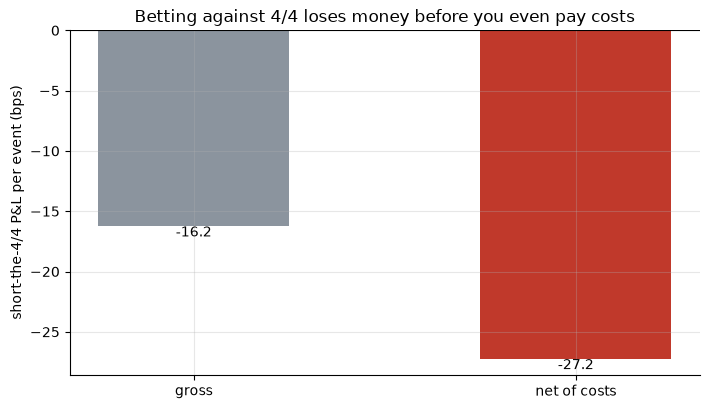

In [6]:
if HAVE_REAL:
    tr = st.short_the_unlucky_day(CA, tickers=data.CALENDAR_CORE)
    g, n = tr['gross_mean']*1e4, tr['mean']*1e4
else:
    g, n = R['short_gross'], R['short_net']
fig, ax = plt.subplots(figsize=(7.2, 4.2))
ax.bar(['gross', 'net of costs'], [g, n], color=[GREY, RED], width=.5)
for i, v in enumerate([g, n]): ax.annotate(f'{v:+.1f}', (i, v), ha='center', va='top')
ax.axhline(0, c='k', lw=.8)
ax.set_ylabel('short-the-4/4 P&L per event (bps)')
ax.set_title('Betting against 4/4 loses money before you even pay costs')
plt.tight_layout(); plt.show()

The short is underwater **gross** (-16.2 bps — the day rose), and costs drag it to **-27.2 bps** net. The tradable folklore is a mirage.

## 5 · The verdict

- **Signal — None.** The 4/4 date does not underperform. Pooled **+16.2 bps**, *t* = **+0.69**, every market positive, placebo *p* = 0.748. No return footprint at all.
- **Tradability — Mirage.** Shorting 4/4 loses **-27.2 bps** per event net.
- **Do Asian prices dodge the 4? — Confirmed.** The trailing digit really does avoid 4 and prefer 8 (*z* = **+4.73**), with a flat US control. The superstition lives in *where prices settle*, not in *when they move*.

## 6 · Going further 🚪

- **This is the cleanest split on the desk.** One belief, two footprints: a *real, confirmed* one in the microstructure (the digits) and a *nonexistent* one in the returns (the date). A belief can be genuinely, measurably true about prices and pure fiction about profits at the same time.
- **Sibling folklore studies:** the [Eurovision effect](../../708-eurovision-effect/) and [plane-crash effect](../../707-plane-crash-effect/) (same event-study machinery), the [Super Bowl indicator](../../158-super-bowl/) and [Olympic years](../../234-olympic-year/) (calendar folklore) — every one tested the same honest way.

*Think a tetraphobic date really moves markets? Try intraday data around a 4/4 open, or the full '4-days' set (the 4th, 14th, 24th), or Lunar-calendar unlucky dates — and show a net, replicated, placebo-surviving edge. We'll publish the teardown.*